<a href="https://colab.research.google.com/github/mohiuddin2806-lang/machine-learning-/blob/main/week10mohi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pyspark

In [2]:
# ── Standard library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
from IPython.display import display, HTML

In [3]:
# ── PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, when, lower, regexp_replace, trim, concat_ws, lit
)
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LinearSVC, LogisticRegression
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)
from pyspark.mllib.evaluation import MulticlassMetrics

In [4]:
# ── Plot style
plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('tab10')

print('✅  All imports successful.')

✅  All imports successful.


In [5]:
spark = (
    SparkSession.builder
    .master('local[*]')
    .appName('CN7030_Lab6_TextClassification')
    .config('spark.driver.memory', '4g')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')  # suppress INFO noise

print(f'✅  Spark {spark.version} started.')
print(f'    Master: {spark.sparkContext.master}')
print(f'    App:    {spark.sparkContext.appName}')

✅  Spark 4.0.4 started.
    Master: local[*]
    App:    CN7030_Lab6_TextClassification


In [7]:
from google.colab import files

print('📤  Please upload your IMDB text file (e.g., train.text or test.text)...')
uploaded  = files.upload()
data_path = next(iter(uploaded.keys()))
print(f'\n✅  Loaded file: {data_path}')

📤  Please upload your IMDB text file (e.g., train.text or test.text)...


Saving aclImdb_v1.tar.gz to aclImdb_v1.tar.gz

✅  Loaded file: aclImdb_v1.tar.gz


In [8]:
# ── Load text
df = spark.read.text("/content/aclImdb_v1.tar.gz")

print('── Schema ──────────────────────────────')
df.printSchema()

print('\n── Sample Rows ─────────────────────────')
df.show(5, truncate=80)

total_rows = df.count()
print(f'\n📊  Total rows: {total_rows:,}')

── Schema ──────────────────────────────
root
 |-- value: string (nullable = true)


── Sample Rows ─────────────────────────
+--------------------------------------------------------------------------------+
|                                                                           value|
+--------------------------------------------------------------------------------+
|aclImdb/                                                                     ...|
|                                                                  0.201363575849|
|                                                                 0.0333946807184|
|                                                                  0.099837669572|
|                                                                -0.0790210365788|
+--------------------------------------------------------------------------------+
only showing top 5 rows

📊  Total rows: 379,146


📦 Extracting dataset...


/tmp/ipykernel_917/4093111635.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='/content/')


✅ Extraction complete.


/tmp/ipykernel_917/4093111635.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category', y='count', data=class_dist_pd, ax=axes[0], palette='tab10')
/tmp/ipykernel_917/4093111635.py:54: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_917/4093111635.py:54: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


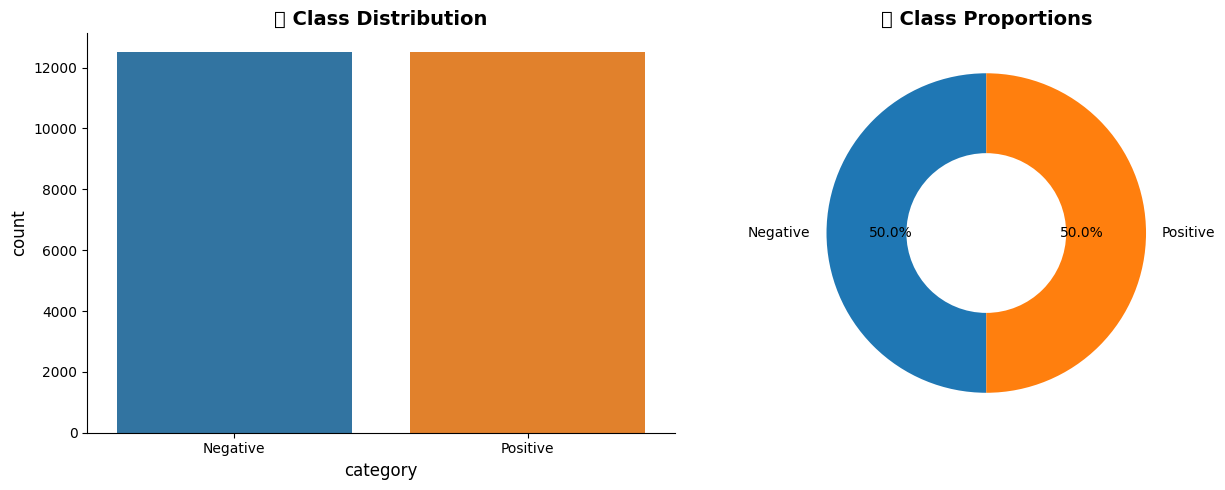

In [9]:
# ── Extract the dataset
import tarfile
import os

if os.path.exists('/content/aclImdb_v1.tar.gz'):
    print('📦 Extracting dataset...')
    with tarfile.open('//content/aclImdb_v1.tar.gz', 'r:gz') as tar:
        tar.extractall(path='/content/')
    print('✅ Extraction complete.')

# ── Load the IMDB dataset into a Spark DataFrame
def load_imdb_subset(path, label_val):
    return spark.read.text(path).withColumn('label', lit(label_val))

train_pos_path = '/content/aclImdb/train/pos/*.txt'
train_neg_path = '/content/aclImdb/train/neg/*.txt'

# Load positive and negative reviews
df_pos = load_imdb_subset(train_pos_path, 1)
df_neg = load_imdb_subset(train_neg_path, 0)

# Combine and rename columns for consistency
df = df_pos.union(df_neg).withColumnRenamed('value', 'text')

# Proceed with analysis
df2 = df
for c in df.columns:
    df2 = df2.withColumnRenamed(c, c.strip().lower())

# ── Resolve label column
label_col_candidates = ['label', 'class', 'category']
label_col = next((c for c in label_col_candidates if c in df2.columns), None)
if label_col is None:
    raise ValueError(f'Cannot find label column. Available: {df2.columns}')

# ── Class distribution
class_dist_pd = (
    df2.groupBy(label_col).count()
    .orderBy(label_col)
    .toPandas()
)

class_names = {1: 'Positive', 0: 'Negative'}
class_dist_pd['category'] = class_dist_pd[label_col].map(lambda x: class_names.get(int(x), str(x)))

# ── Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x='category', y='count', data=class_dist_pd, ax=axes[0], palette='tab10')
axes[0].set_title('📊 Class Distribution', fontweight='bold')

axes[1].pie(class_dist_pd['count'], labels=class_dist_pd['category'], autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.5))
axes[1].set_title('📈 Class Proportions', fontweight='bold')

plt.tight_layout()
plt.show()

✅  Using text column(s): ('text',)

── Binary Label Distribution ──────────────────────
               class  count
Negative (not World)  12500
    Positive (World)  12500


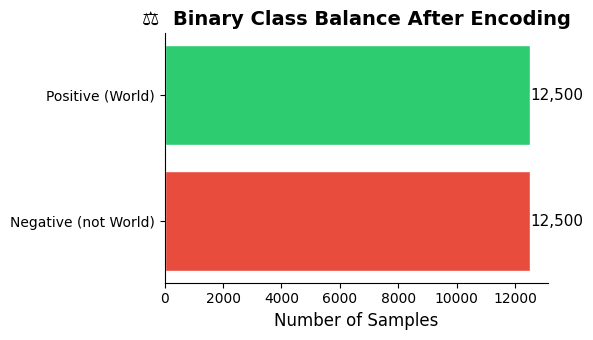


✅  Preprocessing complete.
+--------------------------------------------------------------------------------+-----+
|                                                                            text|label|
+--------------------------------------------------------------------------------+-----+
|match tag team table match bubba ray and spike dudley vs eddie guerrero and c...|  1.0|
|attention spoilers br br first of all let me say that rob roy is one of the b...|  1.0|
|titanic directed by james cameron presents a fictional love story on the hist...|  1.0|
|by now you ve probably heard a bit about the new disney dub of miyazaki s cla...|  1.0|
+--------------------------------------------------------------------------------+-----+
only showing top 4 rows


In [10]:
# ── Resolve text columns
text_candidates = [('title', 'description'), ('title',), ('text',), ('description',)]
text_cols = None
for cand in text_candidates:
    if all(x in df2.columns for x in cand):
        text_cols = cand
        break
if text_cols is None:
    raise ValueError(f'Cannot find text columns. Available: {df2.columns}')
print(f'✅  Using text column(s): {text_cols}')

# ── Combine title + description
if len(text_cols) == 2:
    df2 = df2.withColumn(
        'text_raw',
        concat_ws(' ', col(text_cols[0]).cast('string'), col(text_cols[1]).cast('string'))
    )
else:
    df2 = df2.withColumn('text_raw', col(text_cols[0]).cast('string'))

# ── Binary label
df2 = df2.withColumn('label_raw', col(label_col).cast('int'))
df2 = df2.withColumn('label', when(col('label_raw') == 1, lit(1.0)).otherwise(lit(0.0)))

# ── Text cleaning
df2 = (
    df2
    .withColumn('text', lower(col('text_raw')))
    .withColumn('text', regexp_replace(col('text'), r'[^a-z\s]', ' '))
    .withColumn('text', regexp_replace(col('text'), r'\s+', ' '))
    .withColumn('text', trim(col('text')))
    .select('text', 'label')
    .na.drop()
)

# ── Binary label distribution
print('\n── Binary Label Distribution ──────────────────────')
label_dist = df2.groupBy('label').count().orderBy('label').toPandas()
label_dist['class'] = label_dist['label'].map(
    {0.0: 'Negative (not World)', 1.0: 'Positive (World)'}
)
print(label_dist[['class', 'count']].to_string(index=False))

# ── Visualise binary class balance
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.barh(
    label_dist['class'], label_dist['count'],
    color=['#e74c3c', '#2ecc71'], edgecolor='white'
)
for bar, val in zip(bars, label_dist['count']):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11)
ax.set_xlabel('Number of Samples')
ax.set_title('⚖️  Binary Class Balance After Encoding', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n✅  Preprocessing complete.')
df2.show(4, truncate=80)


📦  Train samples : 19,998  (80.0%)
🧪  Test  samples : 5,002  (20.0%)


/tmp/ipykernel_917/882979313.py:15: UserWarning: Glyph 128256 (\N{TWISTED RIGHTWARDS ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128256 (\N{TWISTED RIGHTWARDS ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


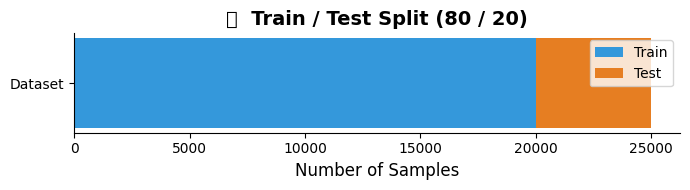

In [11]:
train_df, test_df = df2.randomSplit([0.8, 0.2], seed=42)

n_train = train_df.count()
n_test  = test_df.count()

print(f'📦  Train samples : {n_train:,}  ({n_train/(n_train+n_test)*100:.1f}%)')
print(f'🧪  Test  samples : {n_test:,}  ({n_test/(n_train+n_test)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 2))
ax.barh(['Dataset'], [n_train], color='#3498db', label='Train')
ax.barh(['Dataset'], [n_test],  left=[n_train], color='#e67e22', label='Test')
ax.set_xlabel('Number of Samples')
ax.set_title('🔀  Train / Test Split (80 / 20)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# ── Define TF-IDF pipeline stages
tokenizer = Tokenizer(inputCol='text', outputCol='tokens')
stop_rm   = StopWordsRemover(inputCol='tokens', outputCol='filtered')
hash_tf   = HashingTF(inputCol='filtered', outputCol='tf', numFeatures=2**18)  # 262,144
idf       = IDF(inputCol='tf', outputCol='features')

# ── Fit on TRAINING DATA ONLY (prevents leakage)
featurizer = Pipeline(stages=[tokenizer, stop_rm, hash_tf, idf])
feat_model = featurizer.fit(train_df)

# ── Transform both splits
train_fe = feat_model.transform(train_df)
test_fe  = feat_model.transform(test_df)

print(f'✅  TF-IDF vectors created.')
print(f'    Feature dimensions: {hash_tf.getNumFeatures():,}')
print('\n── Sample feature vectors (sparse) ──────────────────────')
train_fe.select('text', 'features').show(3, truncate=60)

✅  TF-IDF vectors created.
    Feature dimensions: 262,144

── Sample feature vectors (sparse) ──────────────────────
+------------------------------------------------------------+------------------------------------------------------------+
|                                                        text|                                                    features|
+------------------------------------------------------------+------------------------------------------------------------+
|anchors aweigh sees two eager young sailors joe brady gen...|(262144,[991,1102,2081,2325,2437,3924,4319,6946,8145,8449...|
|as with all of angelopoulos films the suspended step of t...|(262144,[2564,3540,3924,4714,5150,6512,6792,7625,8449,853...|
|beat a path to this important documentary that looks like...|(262144,[1398,1578,1889,2549,2988,5381,5765,6038,6498,655...|
+------------------------------------------------------------+------------------------------------------------------------+
only showing t

In [15]:
# ── Define classifiers
lr  = LogisticRegression(featuresCol='features', labelCol='label', maxIter=50)
svm = LinearSVC(featuresCol='features', labelCol='label', maxIter=50, regParam=0.1)

# ── Logistic Regression
print('⏳  Training Logistic Regression baseline...')
t0 = time.time()
pipeline_lr = Pipeline(stages=[tokenizer, stop_rm, hash_tf, idf, lr])
lr_model    = pipeline_lr.fit(train_df)
lr_pred     = lr_model.transform(test_df)
lr_time     = time.time() - t0
print(f'   ✅  Done in {lr_time:.1f}s')

# ── Linear SVM
print('\n⏳  Training Linear SVM...')
t0 = time.time()
pipeline_svm = Pipeline(stages=[tokenizer, stop_rm, hash_tf, idf, svm])
svm_model    = pipeline_svm.fit(train_df)
svm_pred     = svm_model.transform(test_df)
svm_time     = time.time() - t0
print(f'   ✅  Done in {svm_time:.1f}s')

⏳  Training Logistic Regression baseline...
   ✅  Done in 589.2s

⏳  Training Linear SVM...
   ✅  Done in 1306.9s



══════════════ Evaluation Results ══════════════

  Logistic Regression
    Accuracy : 0.8573
    F1 Score : 0.8572
    AUC-ROC  : 0.9233
    Train Time: 589.2s

  Linear SVM
    Accuracy : 0.8876
    F1 Score : 0.8876
    AUC-ROC  : 0.9486
    Train Time: 1306.9s


/tmp/ipykernel_917/2432509407.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


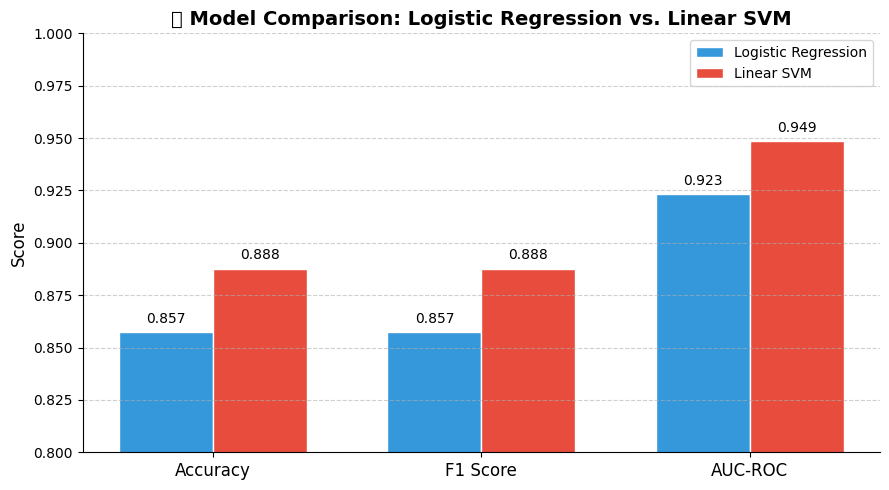

In [16]:
# ── Evaluators
acc_eval = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='accuracy'
)
f1_eval = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='f1'
)
auc_eval = BinaryClassificationEvaluator(
    labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC'
)

lr_acc  = acc_eval.evaluate(lr_pred)
lr_f1   = f1_eval.evaluate(lr_pred)
lr_auc  = auc_eval.evaluate(lr_pred)

svm_acc = acc_eval.evaluate(svm_pred)
svm_f1  = f1_eval.evaluate(svm_pred)
svm_auc = auc_eval.evaluate(svm_pred)

# ── Results table
results = pd.DataFrame({
    'Model':         ['Logistic Regression', 'Linear SVM'],
    'Accuracy':      [lr_acc,  svm_acc],
    'F1 Score':      [lr_f1,   svm_f1],
    'AUC-ROC':       [lr_auc,  svm_auc],
    'Train Time (s)':[lr_time, svm_time]
})

print('\n══════════════ Evaluation Results ══════════════')
for _, row in results.iterrows():
    print(f"\n  {row['Model']}")
    print(f"    Accuracy : {row['Accuracy']:.4f}")
    print(f"    F1 Score : {row['F1 Score']:.4f}")
    print(f"    AUC-ROC  : {row['AUC-ROC']:.4f}")
    print(f"    Train Time: {row['Train Time (s)']:.1f}s")

# ── Bar chart comparison
metrics = ['Accuracy', 'F1 Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, [lr_acc,  lr_f1,  lr_auc],  width, label='Logistic Regression', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, [svm_acc, svm_f1, svm_auc], width, label='Linear SVM',          color='#e74c3c', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=10
    )

ax.set_ylim(0.8, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score')
ax.set_title('📊 Model Comparison: Logistic Regression vs. Linear SVM', fontweight='bold')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_917/3131765624.py:33: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


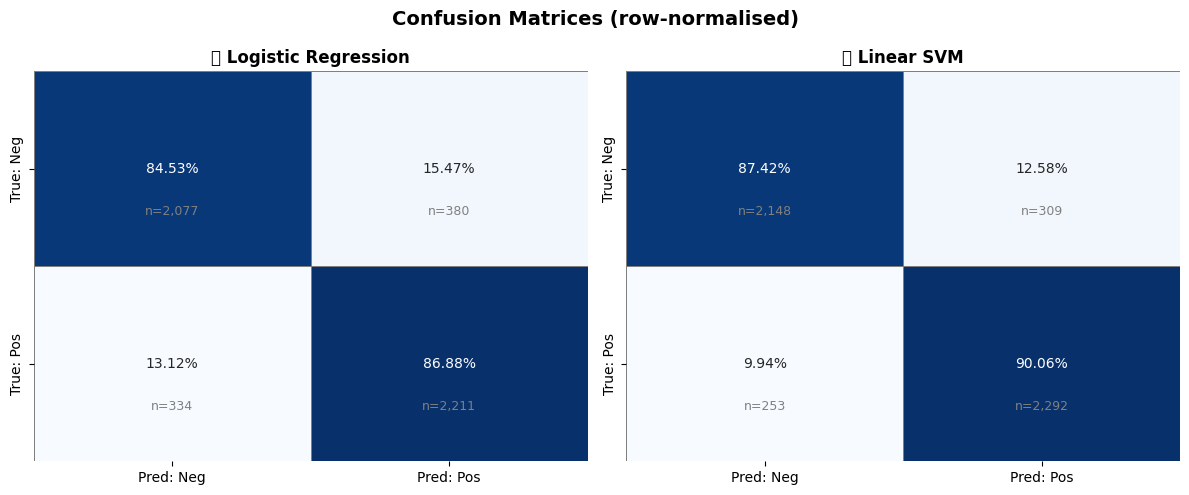


Logistic Regression — raw counts (TN  FP / FN  TP):
[[2077  380]
 [ 334 2211]]

Linear SVM — raw counts (TN  FP / FN  TP):
[[2148  309]
 [ 253 2292]]


In [17]:
def plot_confusion_matrix(pred_df, model_name, ax):
    rdd = pred_df.select('prediction', 'label').rdd.map(
        lambda r: (float(r[0]), float(r[1]))
    )
    cm_metrics = MulticlassMetrics(rdd)
    cm = cm_metrics.confusionMatrix().toArray()
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt='.2%',
        cmap='Blues', ax=ax,
        xticklabels=['Pred: Neg', 'Pred: Pos'],
        yticklabels=['True: Neg', 'True: Pos'],
        linewidths=0.5, linecolor='grey',
        cbar=False
    )
    for i in range(2):
        for j in range(2):
            ax.text(
                j + 0.5, i + 0.72,
                f'n={int(cm[i,j]):,}',
                ha='center', va='center',
                fontsize=9, color='grey'
            )
    ax.set_title(f'🔲 {model_name}', fontweight='bold', fontsize=12)
    return cm

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_lr  = plot_confusion_matrix(lr_pred,  'Logistic Regression', axes[0])
cm_svm = plot_confusion_matrix(svm_pred, 'Linear SVM',          axes[1])

plt.suptitle('Confusion Matrices (row-normalised)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nLogistic Regression — raw counts (TN  FP / FN  TP):')
print(cm_lr.astype(int))
print('\nLinear SVM — raw counts (TN  FP / FN  TP):')
print(cm_svm.astype(int))

/tmp/ipykernel_917/3254807451.py:39: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


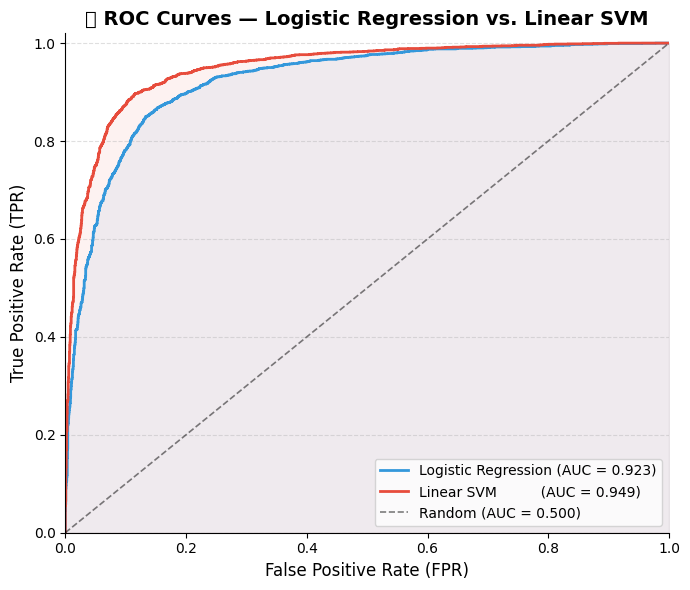

In [18]:
def compute_roc(pred_df, pos_class_idx=1):
    roc_pd = (
        pred_df.select('rawPrediction', 'label').rdd
        .map(lambda r: (float(r['rawPrediction'][pos_class_idx]), float(r['label'])))
        .toDF(['score', 'label'])
        .toPandas()
        .sort_values('score', ascending=False)
    )
    P  = (roc_pd['label'] == 1.0).sum()
    Nn = (roc_pd['label'] == 0.0).sum()
    tpr, fpr, tp, fp, prev = [], [], 0, 0, None
    for score, lab in zip(roc_pd['score'], roc_pd['label']):
        if prev is None or score != prev:
            tpr.append(tp / P if P else 0.0)
            fpr.append(fp / Nn if Nn else 0.0)
            prev = score
        if lab == 1.0: tp += 1
        else:          fp += 1
    tpr.append(1.0); fpr.append(1.0)
    return np.array(fpr), np.array(tpr)

fpr_lr,  tpr_lr  = compute_roc(lr_pred)
fpr_svm, tpr_svm = compute_roc(svm_pred)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_lr,  tpr_lr,  color='#3498db', lw=2, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
ax.plot(fpr_svm, tpr_svm, color='#e74c3c', lw=2, label=f'Linear SVM          (AUC = {svm_auc:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.5, label='Random (AUC = 0.500)')

ax.fill_between(fpr_lr,  tpr_lr,  alpha=0.07, color='#3498db')
ax.fill_between(fpr_svm, tpr_svm, alpha=0.07, color='#e74c3c')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.set_title('📈 ROC Curves — Logistic Regression vs. Linear SVM', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()